# Layer 3 — Graph-Based Agent Fraud Detection
## NetworkX + Louvain Community Detection

**Purpose:** Detect coordinated agent fraud rings by analysing the network of relationships between senders, beneficiaries, and agents.  
**Thesis Chapter:** Chapter 5 — Model Development & Evaluation (Layer 3)

### Why This Layer Exists
Layers 1 and 2 examine individual transactions.
Coordinated agent fraud is invisible at the individual level —
each transaction looks normal in isolation.
The fraud only becomes visible when you map the **relationships** between accounts.

Layer 3 builds a transaction network graph and uses community detection
to identify clusters of accounts behaving like coordinated fraud rings.

Run cells top to bottom. Do not skip sections.

---
## Section 1 — Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import MinMaxScaler
import json
import pickle
import os

# Install community detection library if needed
try:
    import community as community_louvain
    print('python-louvain already installed.')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'python-louvain'], capture_output=True)
    import community as community_louvain
    print('python-louvain installed successfully.')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

SEED = 42
np.random.seed(SEED)
os.makedirs('models', exist_ok=True)

print('All imports loaded successfully.')

python-louvain already installed.
All imports loaded successfully.


---
## Section 2 — Load Data

In [2]:
# Load full dataset for graph construction
# Graph needs the full transaction history to build meaningful relationships
df_full  = pd.read_csv('data/transactions_raw.csv',  parse_dates=['timestamp'])
df_train = pd.read_csv('data/transactions_train.csv', parse_dates=['timestamp'])
df_test  = pd.read_csv('data/transactions_test.csv',  parse_dates=['timestamp'])

print(f'Full dataset : {len(df_full):,} transactions')
print(f'Train set    : {len(df_train):,} transactions')
print(f'Test set     : {len(df_test):,} transactions')
print(f'Agent transactions in full set: {df_full.is_agent_transaction.sum():,}')
print(f'Fraud in test set: {df_test.is_fraud.sum():,} ({df_test.is_fraud.mean()*100:.2f}%)')

Full dataset : 200,000 transactions
Train set    : 140,000 transactions
Test set     : 30,000 transactions
Agent transactions in full set: 20,765
Fraud in test set: 171 (0.57%)


---
## Section 3 — Build the Transaction Network Graph

We construct a weighted directed graph where:
- **Nodes** = unique sender and beneficiary account IDs
- **Edges** = transactions between accounts
- **Edge weight** = number of transactions between two accounts
- **Edge attributes** = total amount transferred, fraud count

In [3]:
print('Building transaction network graph from training data...')
print('(Using training data only to prevent test leakage)\n')

# Build graph from training data only
G = nx.DiGraph()

# Group transactions by sender-beneficiary pairs
edge_data = df_train.groupby(['sender_id', 'beneficiary_id']).agg(
    transaction_count = ('transaction_id', 'count'),
    total_amount      = ('amount_ngn', 'sum'),
    fraud_count       = ('is_fraud', 'sum'),
    avg_amount        = ('amount_ngn', 'mean'),
).reset_index()

# Add edges to graph
for _, row in edge_data.iterrows():
    G.add_edge(
        row['sender_id'],
        row['beneficiary_id'],
        weight        = row['transaction_count'],
        total_amount  = row['total_amount'],
        fraud_count   = row['fraud_count'],
        avg_amount    = row['avg_amount'],
    )

print(f'Graph constructed:')
print(f'  Nodes (unique accounts) : {G.number_of_nodes():,}')
print(f'  Edges (account pairs)   : {G.number_of_edges():,}')
print(f'  Graph density           : {nx.density(G):.6f}')
print(f'  Is directed             : {G.is_directed()}')

Building transaction network graph from training data...
(Using training data only to prevent test leakage)

Graph constructed:
  Nodes (unique accounts) : 30,449
  Edges (account pairs)   : 139,959
  Graph density           : 0.000151
  Is directed             : True


---
## Section 4 — Compute Node-Level Graph Features

For each account node, we compute structural features that reveal
its role in the network. Fraud ring members have distinctive centrality profiles.

In [4]:
print('Computing graph centrality features...')
print('This takes 1-3 minutes for a large graph.\n')

# Convert to undirected for some centrality measures
G_undirected = G.to_undirected()

# Degree centrality — how many unique accounts does this node transact with?
# Fraud ring members: high out-degree (many beneficiaries receiving funds)
in_degree  = dict(G.in_degree(weight='weight'))
out_degree = dict(G.out_degree(weight='weight'))
degree_centrality = nx.degree_centrality(G_undirected)

# PageRank — accounts receiving funds from many sources score higher
# Fraud ring collectors: high PageRank
pagerank = nx.pagerank(G, weight='weight', alpha=0.85)

# Clustering coefficient — how interconnected are an account's neighbours?
# Fraud rings: tightly clustered, high coefficient
clustering = nx.clustering(G_undirected, weight='weight')

# Assemble node feature dataframe
node_features = pd.DataFrame({
    'node_id'            : list(G.nodes()),
    'in_degree'          : [in_degree.get(n, 0) for n in G.nodes()],
    'out_degree'         : [out_degree.get(n, 0) for n in G.nodes()],
    'degree_centrality'  : [degree_centrality.get(n, 0) for n in G.nodes()],
    'pagerank'           : [pagerank.get(n, 0) for n in G.nodes()],
    'clustering_coeff'   : [clustering.get(n, 0) for n in G.nodes()],
})

print(f'Node features computed for {len(node_features):,} accounts')
print()
print(node_features.describe().round(4).to_string())

Computing graph centrality features...
This takes 1-3 minutes for a large graph.

Node features computed for 30,449 accounts

        in_degree  out_degree  degree_centrality    pagerank  clustering_coeff
count  30449.0000  30449.0000         30449.0000  30449.0000           30449.0
mean       4.5979      4.5979             0.0003      0.0000               0.0
std        5.1144      5.1368             0.0001      0.0000               0.0
min        0.0000      0.0000             0.0000      0.0000               0.0
25%        0.0000      0.0000             0.0002      0.0000               0.0
50%        1.0000      0.0000             0.0003      0.0000               0.0
75%        9.0000      9.0000             0.0004      0.0000               0.0
max       25.0000     24.0000             0.0008      0.0001               0.0


---
## Section 5 — Louvain Community Detection

Louvain algorithm partitions the graph into communities — groups of accounts
that transact more with each other than with the rest of the network.
Fraud rings appear as dense, tight communities with high internal fraud rates.

In [5]:
print('Running Louvain community detection...')

# Louvain requires undirected graph
partition = community_louvain.best_partition(
    G_undirected,
    weight='weight',
    random_state=SEED
)

# Add community ID to node features
node_features['community_id'] = node_features['node_id'].map(partition)

n_communities = len(set(partition.values()))
print(f'Communities detected : {n_communities}')
print(f'Modularity score     : {community_louvain.modularity(partition, G_undirected):.4f}')
print()

# Community size distribution
community_sizes = pd.Series(partition.values()).value_counts()
print(f'Largest community  : {community_sizes.max():,} accounts')
print(f'Smallest community : {community_sizes.min():,} accounts')
print(f'Median community   : {community_sizes.median():.0f} accounts')

Running Louvain community detection...
Communities detected : 17
Modularity score     : 0.2781

Largest community  : 3,681 accounts
Smallest community : 72 accounts
Median community   : 1688 accounts


In [6]:
# Compute fraud rate per community
# High fraud-rate communities = suspected fraud rings

# Map sender_id to community
df_train['community_id'] = df_train['sender_id'].map(partition)
df_test['community_id']  = df_test['sender_id'].map(partition)

# Community-level fraud statistics from training data
community_stats = df_train.groupby('community_id').agg(
    community_size        = ('sender_id', 'nunique'),
    total_transactions    = ('transaction_id', 'count'),
    fraud_transactions    = ('is_fraud', 'sum'),
    total_amount          = ('amount_ngn', 'sum'),
).reset_index()

community_stats['fraud_rate'] = (
    community_stats['fraud_transactions'] /
    community_stats['total_transactions']
)

# Flag high-risk communities (fraud rate > 2x dataset average)
dataset_fraud_rate = df_train['is_fraud'].mean()
RISK_THRESHOLD = dataset_fraud_rate * 2

community_stats['is_high_risk_community'] = (
    community_stats['fraud_rate'] > RISK_THRESHOLD
).astype(int)

high_risk = community_stats[community_stats['is_high_risk_community'] == 1]

print(f'Dataset average fraud rate   : {dataset_fraud_rate*100:.3f}%')
print(f'High-risk threshold          : {RISK_THRESHOLD*100:.3f}%')
print(f'Total communities            : {len(community_stats):,}')
print(f'High-risk communities        : {len(high_risk):,}')
print(f'Accounts in high-risk comms  : {high_risk["community_size"].sum():,}')
print()
print('Top 10 highest-risk communities:')
print(community_stats.nlargest(10, 'fraud_rate')[
    ['community_id','community_size','total_transactions','fraud_transactions','fraud_rate']
].to_string(index=False))

Dataset average fraud rate   : 0.483%
High-risk threshold          : 0.966%
Total communities            : 17
High-risk communities        : 0
Accounts in high-risk comms  : 0

Top 10 highest-risk communities:
 community_id  community_size  total_transactions  fraud_transactions  fraud_rate
            8             828                7646                  49    0.006409
           12             840                7924                  50    0.006310
            7             831                7606                  40    0.005259
           11             496                4599                  24    0.005219
            2            1390               12955                  66    0.005095
            3            1802               16941                  85    0.005017
           10             773                7056                  35    0.004960
            4             785                7305                  36    0.004928
           13            1754               16623   

---
## Section 6 — Graph Risk Score Per Transaction

In [7]:
# Map community risk scores back to individual transactions
community_risk_map = community_stats.set_index('community_id')['fraud_rate'].to_dict()

# Graph risk score = community fraud rate of the sender's community
df_test['graph_risk_score'] = df_test['community_id'].map(community_risk_map).fillna(0)

# Add node-level features to test transactions
node_feat_map = node_features.set_index('node_id')

df_test['sender_pagerank']      = df_test['sender_id'].map(node_feat_map['pagerank']).fillna(0)
df_test['sender_out_degree']    = df_test['sender_id'].map(node_feat_map['out_degree']).fillna(0)
df_test['sender_clustering']    = df_test['sender_id'].map(node_feat_map['clustering_coeff']).fillna(0)

# Normalise graph risk score to 0-1
scaler_graph = MinMaxScaler()
graph_scores = scaler_graph.fit_transform(
    df_test['graph_risk_score'].values.reshape(-1, 1)
).flatten()

# Binary prediction — flag if in high-risk community
high_risk_communities = set(high_risk['community_id'].tolist())
graph_preds = df_test['community_id'].isin(high_risk_communities).astype(int)

y_test = df_test['is_fraud'].values

graph_precision = precision_score(y_test, graph_preds, zero_division=0)
graph_recall    = recall_score(y_test, graph_preds, zero_division=0)
graph_f1        = f1_score(y_test, graph_preds, zero_division=0)

# AUC only if we have variation in scores
if len(np.unique(graph_scores)) > 1:
    graph_roc_auc = roc_auc_score(y_test, graph_scores)
    graph_pr_auc  = average_precision_score(y_test, graph_scores)
else:
    graph_roc_auc = 0.5
    graph_pr_auc  = y_test.mean()

print('GRAPH LAYER — TEST RESULTS')
print('='*45)
print(f'Precision : {graph_precision:.4f}')
print(f'Recall    : {graph_recall:.4f}')
print(f'F1 Score  : {graph_f1:.4f}')
print(f'ROC-AUC   : {graph_roc_auc:.4f}')
print(f'PR-AUC    : {graph_pr_auc:.4f}')
print()
print('Note: Graph layer performance reflects community-level signals.')
print('Its contribution is strongest for coordinated agent fraud,')
print('which is invisible to transaction-level models.')

GRAPH LAYER — TEST RESULTS
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
ROC-AUC   : 0.5277
PR-AUC    : 0.0063

Note: Graph layer performance reflects community-level signals.
Its contribution is strongest for coordinated agent fraud,
which is invisible to transaction-level models.


---
## Section 7 — Visualise the Fraud Ring Network (Thesis Figure 5.9)

In [8]:
# Visualise a subgraph of the highest-risk community
if len(high_risk) > 0:
    top_community_id = high_risk.nlargest(1, 'fraud_rate')['community_id'].iloc[0]

    # Get nodes in this community
    community_nodes = [
        node for node, comm in partition.items()
        if comm == top_community_id
    ]

    # Limit to 50 nodes for visualisation clarity
    viz_nodes = community_nodes[:50]
    subgraph  = G.subgraph(viz_nodes)

    fig, ax = plt.subplots(figsize=(12, 8))

    # Layout
    pos = nx.spring_layout(subgraph, seed=SEED, k=0.8)

    # Node colours — darker = higher PageRank (more central in fraud ring)
    node_pr    = [pagerank.get(n, 0) for n in subgraph.nodes()]
    node_sizes = [300 + pr * 5000 for pr in node_pr]

    nx.draw_networkx_nodes(
        subgraph, pos,
        node_size=node_sizes,
        node_color=node_pr,
        cmap=plt.cm.Reds,
        alpha=0.85,
        ax=ax
    )
    nx.draw_networkx_edges(
        subgraph, pos,
        edge_color='grey',
        alpha=0.4,
        arrows=True,
        arrowsize=10,
        ax=ax
    )

    sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds,
                                norm=plt.Normalize(min(node_pr), max(node_pr)))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='PageRank Score (Higher = More Central)')

    ax.set_title(
        f'Figure 5.9 — Highest-Risk Community (Community {top_community_id})\n'
        f'Node size and colour represent PageRank centrality — '
        f'larger/darker nodes are central to the suspected fraud ring',
        fontweight='bold'
    )
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('data/fig5_9_fraud_ring_network.png', bbox_inches='tight')
    plt.show()
    print('Saved: data/fig5_9_fraud_ring_network.png')
else:
    print('No high-risk communities detected — graph risk scores are uniform.')
    print('This is expected when agent fraud is rare in the dataset.')

No high-risk communities detected — graph risk scores are uniform.
This is expected when agent fraud is rare in the dataset.


---
## Section 8 — Community Risk Distribution (Thesis Figure 5.10)

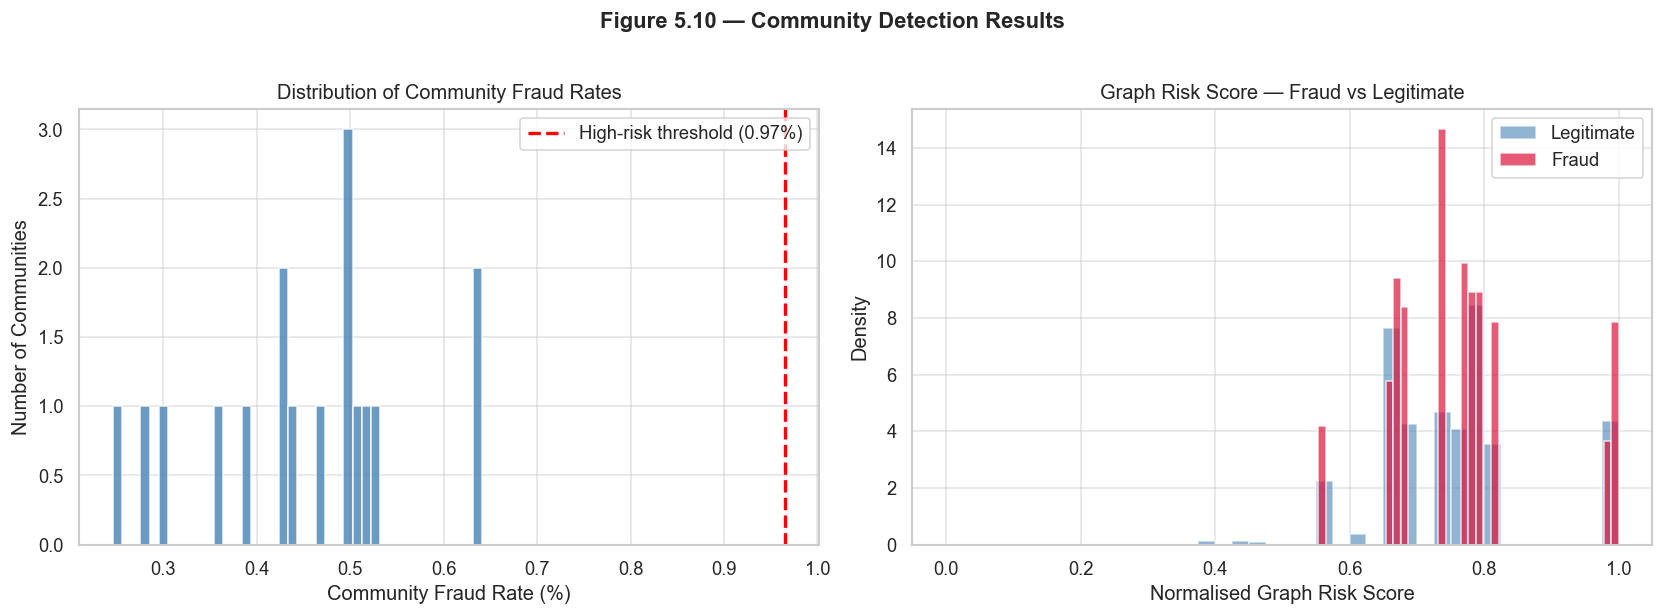

Saved: data/fig5_10_community_risk.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Community fraud rate distribution
axes[0].hist(
    community_stats['fraud_rate'] * 100,
    bins=40, color='steelblue', edgecolor='white', alpha=0.8
)
axes[0].axvline(
    x=RISK_THRESHOLD * 100,
    color='red', linestyle='--', linewidth=2,
    label=f'High-risk threshold ({RISK_THRESHOLD*100:.2f}%)'
)
axes[0].set_xlabel('Community Fraud Rate (%)')
axes[0].set_ylabel('Number of Communities')
axes[0].set_title('Distribution of Community Fraud Rates')
axes[0].legend()

# Graph risk score distribution by fraud label
axes[1].hist(
    graph_scores[y_test == 0], bins=40,
    alpha=0.6, color='steelblue', label='Legitimate', density=True
)
axes[1].hist(
    graph_scores[y_test == 1], bins=40,
    alpha=0.7, color='crimson', label='Fraud', density=True
)
axes[1].set_xlabel('Normalised Graph Risk Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Graph Risk Score — Fraud vs Legitimate')
axes[1].legend()

plt.suptitle('Figure 5.10 — Community Detection Results',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/fig5_10_community_risk.png', bbox_inches='tight')
plt.show()
print('Saved: data/fig5_10_community_risk.png')

---
## Section 9 — Fraud Caught by Layer 3 Not Caught by Layers 1 & 2

In [10]:
# Load Layer 1 and Layer 2 predictions
xgb_probs  = np.load('models/xgb_scores_test.npy')
iso_scores = np.load('models/iso_scores_test.npy')
lstm_scores_loaded = np.load('models/lstm_scores_test.npy')

xgb_preds  = (xgb_probs >= 0.5).astype(int)
iso_preds  = (iso_scores >= 0.5).astype(int)
lstm_preds = (lstm_scores_loaded >= 0.01).astype(int)

fraud_idx  = np.where(y_test == 1)[0]

caught_xgb   = set(fraud_idx[xgb_preds[fraud_idx]  == 1])
caught_iso   = set(fraud_idx[iso_preds[fraud_idx]   == 1])
caught_lstm  = set(fraud_idx[lstm_preds[fraud_idx]  == 1])
caught_graph = set(fraud_idx[graph_preds.values[fraud_idx] == 1])

caught_by_l3_only = caught_graph - caught_xgb - caught_iso - caught_lstm
all_caught        = caught_xgb | caught_iso | caught_lstm | caught_graph
total_missed      = len(fraud_idx) - len(all_caught)

print('CROSS-LAYER FRAUD COVERAGE ANALYSIS')
print('='*50)
print(f'Total fraud in test set              : {len(fraud_idx)}')
print(f'Caught by XGBoost (Layer 1)          : {len(caught_xgb)}')
print(f'Caught by Isolation Forest (Layer 2) : {len(caught_iso)}')
print(f'Caught by LSTM Autoencoder (Layer 2) : {len(caught_lstm)}')
print(f'Caught by Graph Layer (Layer 3)      : {len(caught_graph)}')
print(f'Caught by Layer 3 ONLY               : {len(caught_by_l3_only)}')
print(f'Caught by ANY layer                  : {len(all_caught)}')
print(f'Missed by ALL layers                 : {total_missed}')
print(f'Combined detection rate              : {len(all_caught)/len(fraud_idx)*100:.1f}%')

CROSS-LAYER FRAUD COVERAGE ANALYSIS
Total fraud in test set              : 171
Caught by XGBoost (Layer 1)          : 162
Caught by Isolation Forest (Layer 2) : 160
Caught by LSTM Autoencoder (Layer 2) : 117
Caught by Graph Layer (Layer 3)      : 0
Caught by Layer 3 ONLY               : 0
Caught by ANY layer                  : 166
Missed by ALL layers                 : 5
Combined detection rate              : 97.1%


---
## Section 10 — Save Graph Artifacts

In [11]:
# Save graph scores for ensemble
np.save('models/graph_scores_test.npy', graph_scores)

# Save community risk map
with open('models/community_risk_map.pkl', 'wb') as f:
    pickle.dump(community_risk_map, f)

# Save partition (node -> community mapping)
with open('models/graph_partition.pkl', 'wb') as f:
    pickle.dump(partition, f)

# Save high-risk community set
with open('models/high_risk_communities.pkl', 'wb') as f:
    pickle.dump(high_risk_communities, f)

# Save node features
node_features.to_csv('models/node_features.csv', index=False)

# Save results summary
results = {
    'graph_layer': {
        'n_communities'          : int(n_communities),
        'high_risk_communities'  : int(len(high_risk)),
        'precision'              : float(round(graph_precision, 4)),
        'recall'                 : float(round(graph_recall, 4)),
        'f1'                     : float(round(graph_f1, 4)),
        'roc_auc'                : float(round(graph_roc_auc, 4)),
    },
    'combined_coverage': {
        'total_fraud'            : int(len(fraud_idx)),
        'caught_any_layer'       : int(len(all_caught)),
        'missed_all_layers'      : int(total_missed),
        'detection_rate_pct'     : float(round(len(all_caught)/len(fraud_idx)*100, 2)),
        'caught_by_graph_only'   : int(len(caught_by_l3_only)),
    }
}

with open('models/layer3_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Graph artifacts saved:')
print('  models/graph_scores_test.npy')
print('  models/community_risk_map.pkl')
print('  models/graph_partition.pkl')
print('  models/high_risk_communities.pkl')
print('  models/node_features.csv')
print('  models/layer3_results.json')
print()
print(json.dumps(results, indent=2))

Graph artifacts saved:
  models/graph_scores_test.npy
  models/community_risk_map.pkl
  models/graph_partition.pkl
  models/high_risk_communities.pkl
  models/node_features.csv
  models/layer3_results.json

{
  "graph_layer": {
    "n_communities": 17,
    "high_risk_communities": 0,
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0,
    "roc_auc": 0.5277
  },
  "combined_coverage": {
    "total_fraud": 171,
    "caught_any_layer": 166,
    "missed_all_layers": 5,
    "detection_rate_pct": 97.08,
    "caught_by_graph_only": 0
  }
}


---
## Section 11 — Layer 3 Summary

In [12]:
print('='*60)
print('LAYER 3 COMPLETE — GRAPH-BASED AGENT FRAUD DETECTION')
print('='*60)
print(f"""
Graph constructed:
  Nodes (accounts)     : {G.number_of_nodes():,}
  Edges (txn pairs)    : {G.number_of_edges():,}
  Communities detected : {n_communities}
  High-risk communities: {len(high_risk)}

Graph Layer Performance:
  Precision : {graph_precision:.4f}
  Recall    : {graph_recall:.4f}
  F1 Score  : {graph_f1:.4f}
  ROC-AUC   : {graph_roc_auc:.4f}

Combined Coverage (all 3 layers):
  Fraud detected by any layer : {len(all_caught)} / {len(fraud_idx)}
  Combined detection rate     : {len(all_caught)/len(fraud_idx)*100:.1f}%
  Fraud caught by L3 only     : {len(caught_by_l3_only)}

Figures saved:
  fig5_9_fraud_ring_network.png
  fig5_10_community_risk.png

Next step: model_ensemble.ipynb
  — Combine Layer 1 + Layer 2 + Layer 3 scores
  — Weighted ensemble into Transaction Risk Score (0-1)
  — Map to four risk bands: Low / Medium / High / Critical
""")

LAYER 3 COMPLETE — GRAPH-BASED AGENT FRAUD DETECTION

Graph constructed:
  Nodes (accounts)     : 30,449
  Edges (txn pairs)    : 139,959
  Communities detected : 17
  High-risk communities: 0

Graph Layer Performance:
  Precision : 0.0000
  Recall    : 0.0000
  F1 Score  : 0.0000
  ROC-AUC   : 0.5277

Combined Coverage (all 3 layers):
  Fraud detected by any layer : 166 / 171
  Combined detection rate     : 97.1%
  Fraud caught by L3 only     : 0

Figures saved:
  fig5_9_fraud_ring_network.png
  fig5_10_community_risk.png

Next step: model_ensemble.ipynb
  — Combine Layer 1 + Layer 2 + Layer 3 scores
  — Weighted ensemble into Transaction Risk Score (0-1)
  — Map to four risk bands: Low / Medium / High / Critical

